In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
dataset = BNCI2014008()
subject, session, run = 2, "session_0", "run_0"

In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.797 sec
Baseline,off


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('numpy')

X = epochs.get_data().astype(np.float64)
y = labels

X.shape


(4200, 8, 52)

In [5]:
import cupy
from hoda.hoda import HODA, mode_scatter


hoda = HODA(
            rank=None,
            max_iter=64,
            tol=1e-6,
            init ='mlsvd',
            shrinkage=(0,0),
            toeplitz=None,
            obj='diff',
            solver='lanczos',
            taper=False,
            keep_train_info=True,
            verbose=True,
        )
hoda.fit(X,y)

Initializing factors...
Fitting discriminative tucker model of rank [1, 1] ...


  0%|          | 0/64 [00:00<?, ?it/s]

HODA(keep_train_info=True, max_iter=64, obj='diff', shrinkage=(0, 0), tol=1e-06,
     verbose=True)

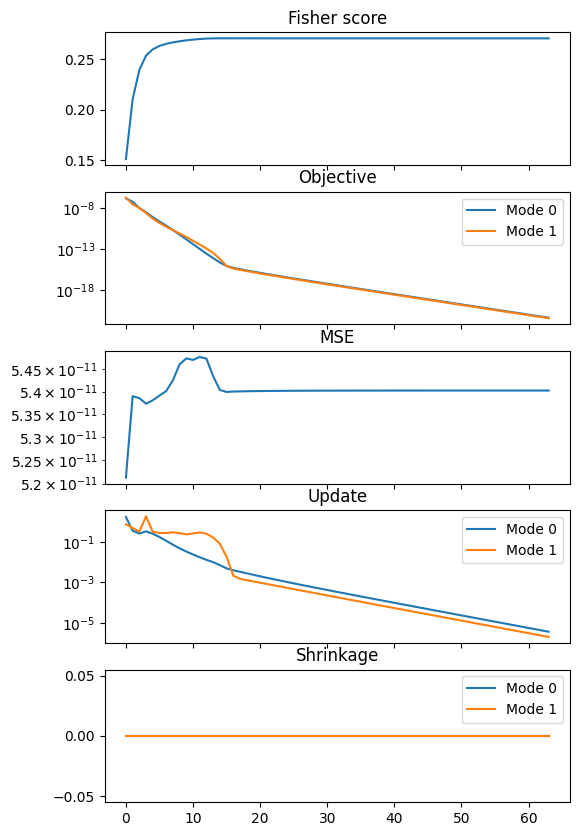

In [6]:
fig, axs = plt.subplots(5,1, sharex=True, figsize=(6,10))

axs[0].set_title('Fisher score')
axs[0].plot(hoda.train_info_["f_score"])

axs[1].set_title('Objective')
axs[1].semilogy(np.asarray(hoda.train_info_["mode_objective"]).T, label=['Mode 0', 'Mode 1'])
axs[1].legend()

axs[2].set_title('MSE')
axs[2].semilogy(hoda.train_info_["mse"])

axs[3].set_title('Update')
axs[3].semilogy(np.asarray(hoda.train_info_["mode_update"]).T, label=['Mode 0', 'Mode 1'])
axs[3].legend()

axs[4].set_title('Shrinkage')
axs[4].plot(np.asarray(hoda.train_info_["mode_shrinkage"]).T, label=['Mode 0', 'Mode 1'])
axs[4].legend()

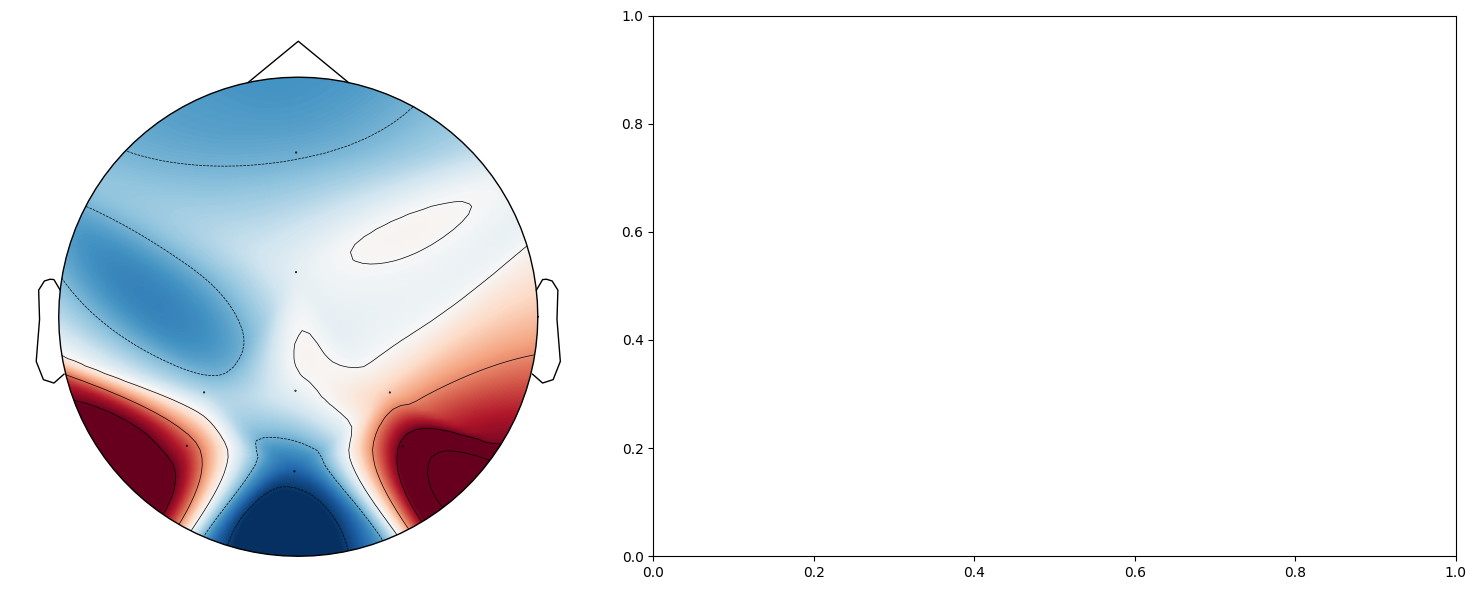

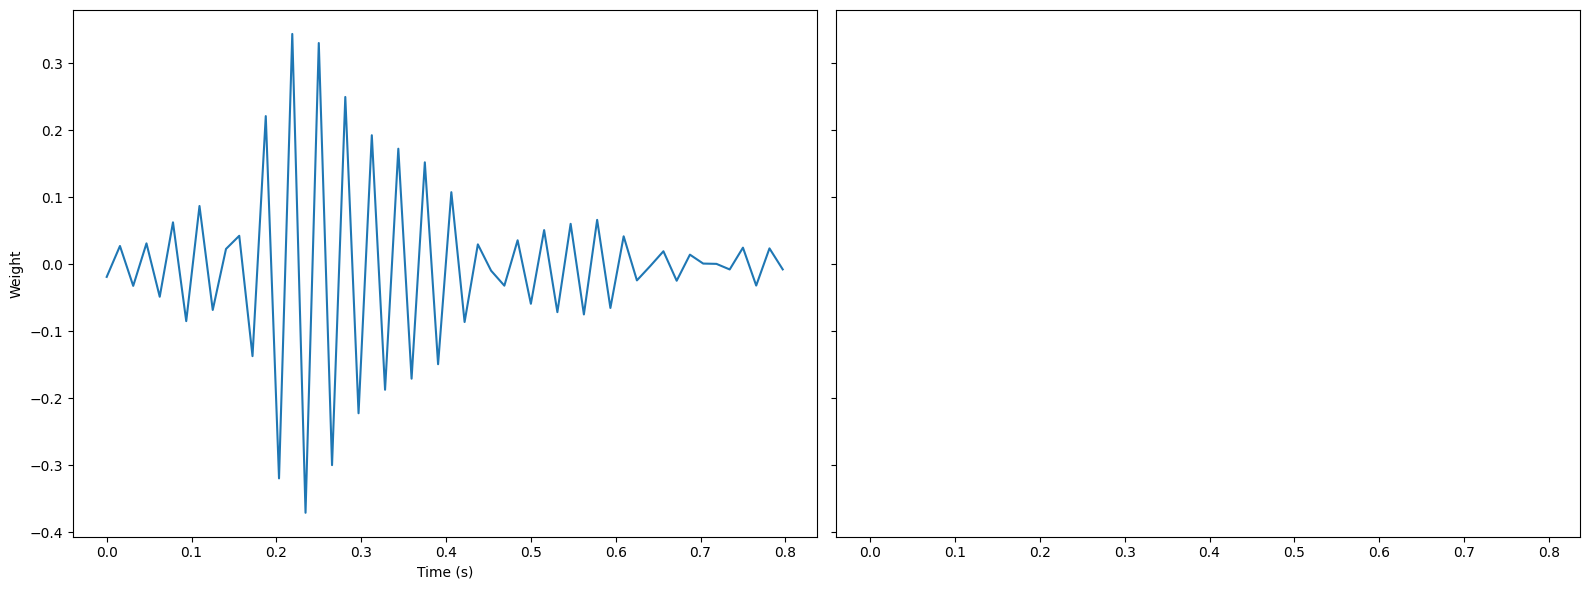

In [7]:
fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,max(hoda.rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Weight');


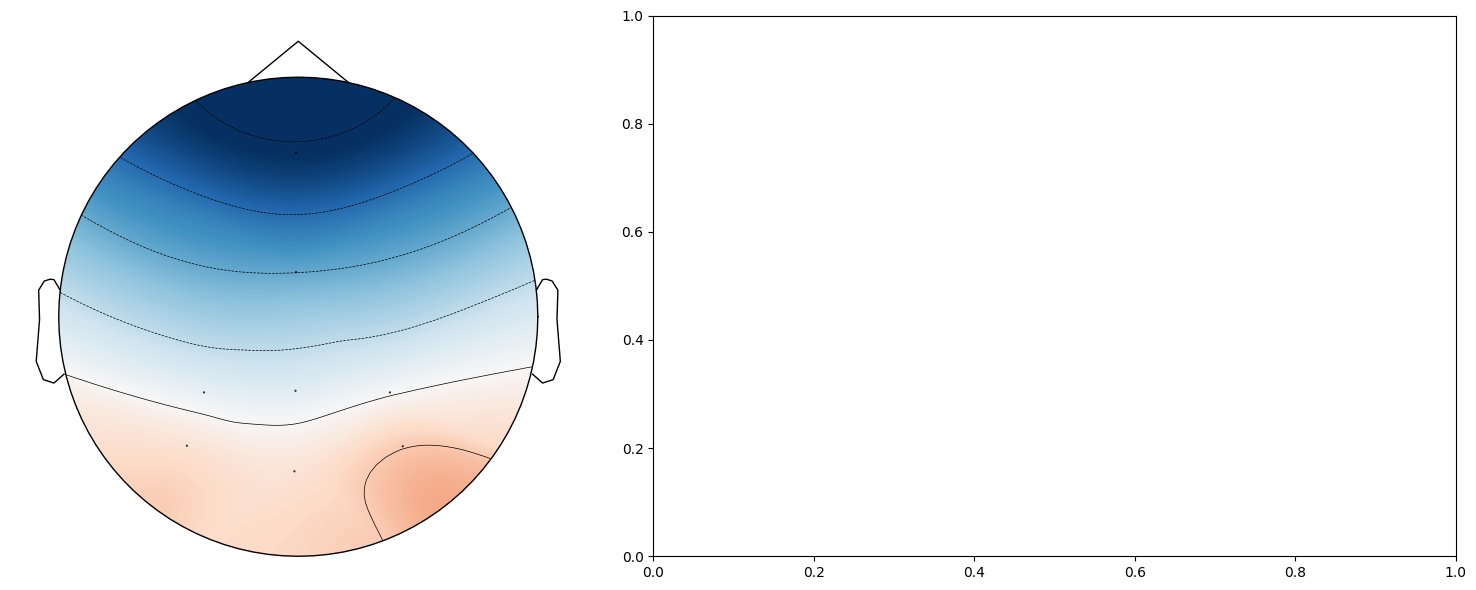

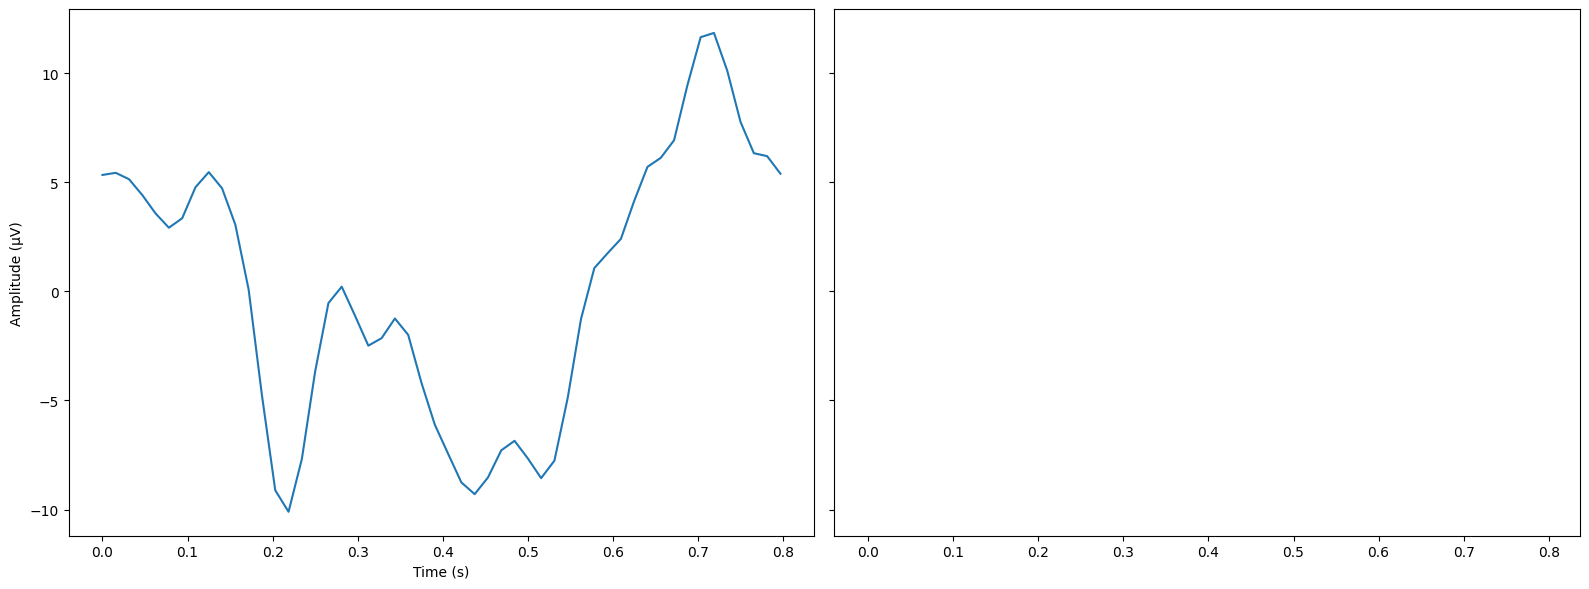

In [8]:

fig, axs = plt.subplots(1,max(hoda.rank_[0],2), figsize=(16,6), layout='tight')
A = hoda.cov_w_[0] @ hoda.scalings_[0] @ hoda.cov_l_inv_[0]
for i in range(hoda.rank_[0]):
    a = cupy.asnumpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs[i], show=False)

    
fig, axs = plt.subplots(
    1,max(hoda.rank_[1],2),
    figsize=(16,6),
    layout='tight', 
    sharex=True,
    sharey=True
)

A = hoda.cov_w_[1] @ hoda.scalings_[1] @ hoda.cov_l_inv_[1]

for i in range(hoda.rank_[1]):
    a = cupy.asnumpy(A[:,i])
    axs[i].plot(epochs.times, a)
    axs[i].set_xlabel('Time (s)')
    axs[i].sharey(axs[0])
axs[0].set_ylabel('Amplitude (µV)');

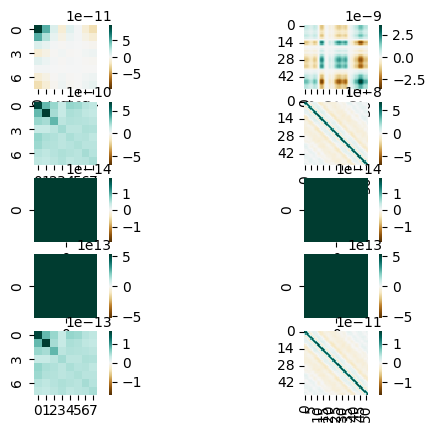

In [9]:
_, axs = plt.subplots(5,2)
for k in range(2):
    
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[0,k].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[0,k])    
    
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[1,k])    
    axs[1,k].set_aspect('equal')

    cov_l= cupy.asnumpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[2,k])    
    axs[2,k].set_aspect('equal')
    
    cov_l_inv= cupy.asnumpy(hoda.cov_l_inv_[k])
    vmax = np.max(np.abs(cov_l_inv))
    sns.heatmap(cov_l_inv, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[3,k])    
    axs[3,k].set_aspect('equal')
    
    cov_w= cupy.asnumpy(hoda.cov_w_[k])
    vmax = np.max(np.abs(cov_w))
    sns.heatmap(cov_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[4,k])    
    axs[4,k].set_aspect('equal')

In [10]:
Xt = hoda.transform(X)
Xt

array([[[-1.33678355e-07]],

       [[ 8.73908759e-08]],

       [[-1.43873247e-07]],

       ...,

       [[-1.09807605e-07]],

       [[ 3.27445748e-08]],

       [[-6.50552499e-08]]])

<AxesSubplot: >

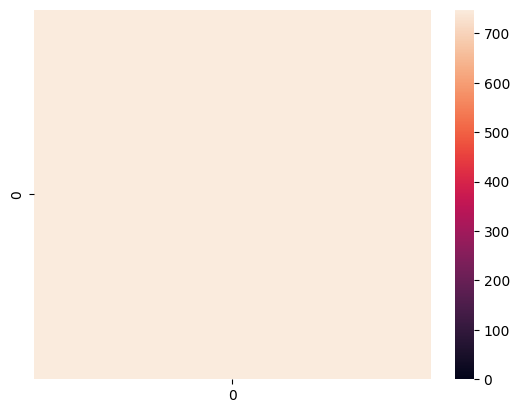

In [11]:
import scipy.stats
import seaborn as sns

samples = []
for c in hoda.classes_:
    samples.append(cupy.asnumpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
sns.heatmap(F, vmin=0)



<AxesSubplot: >

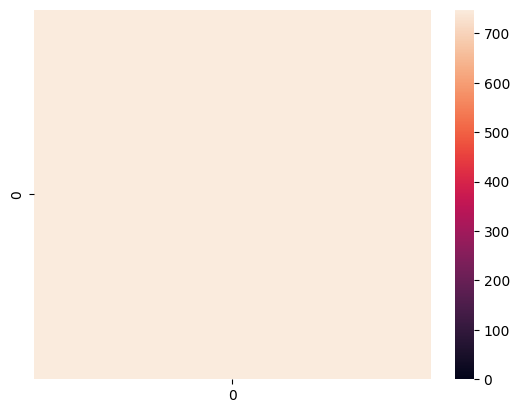

In [12]:
sns.heatmap(F, mask=p>0.05,vmin=0)


No projector specified for this dataset. Please consider the method self.add_proj.


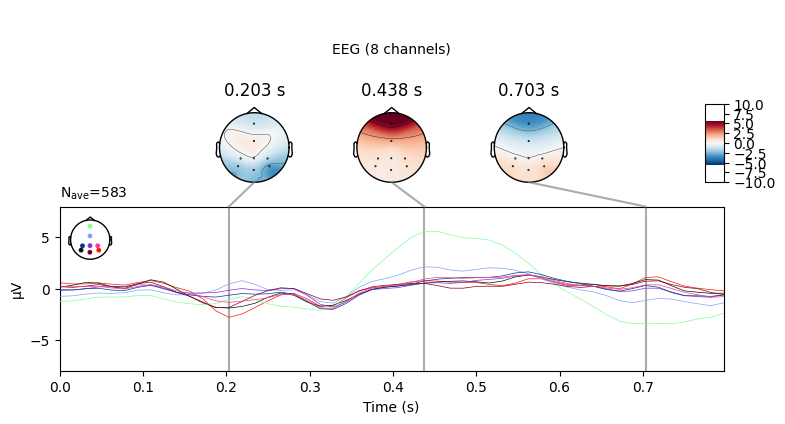

No projector specified for this dataset. Please consider the method self.add_proj.


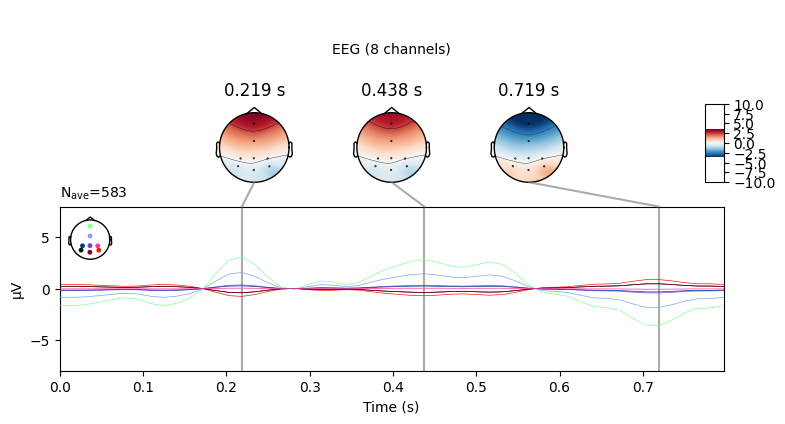

No projector specified for this dataset. Please consider the method self.add_proj.


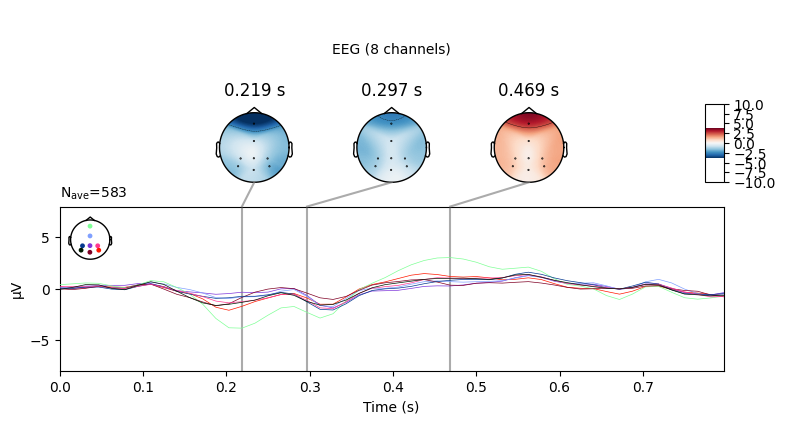

In [13]:
joint_args=dict(
    ts_args=dict(
        ylim=dict(eeg=[-8,8]),
        unit=True,
    )
)

target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_rec = epochs.copy()
epochs_rec._data = hoda.inv_transform(hoda.transform(epochs.get_data()))

target = epochs_rec['Target'].average()
non_target = epochs_rec['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

epochs_defl = epochs.copy()
epochs_defl._data -= epochs_rec.get_data()

target = epochs_defl['Target'].average()
non_target = epochs_defl['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(**joint_args)

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score

Xt = hoda.transform(X)
Xt_flat = Xt.reshape((Xt.shape[0],-1))
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr') 
lda.fit(Xt_flat, y)
score_pred = lda.decision_function(Xt_flat)
print(roc_auc_score(y,score_pred))

0.7658024489795918
